In [2]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [3]:
class Problem(ABC):
    """Abstract base class for a search problem."""
    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass
    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass
    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass
    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass
    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""

In [4]:
"""-----Section 3-----"""
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1

@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path

In [5]:
"""-----Section 4-----"""
def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [6]:
"""-----Section 5-----"""
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        return self.goal == state
        raise NoImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        legal_actions = []
        for action in MOVES:
            dr,dc = MOVES[action]
            row,col = state
            new_state = dr+row, dc+col
            if self.in_bounds(new_state) and self.is_free(new_state):
                legal_actions.append(action)
        return legal_actions

        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        row,col=state
        dr,dc=MOVES[action]
        return (row+dr,col+dc)

        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")

In [7]:
"""Section 5.1"""
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [8]:
"""Section 6"""
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [9]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

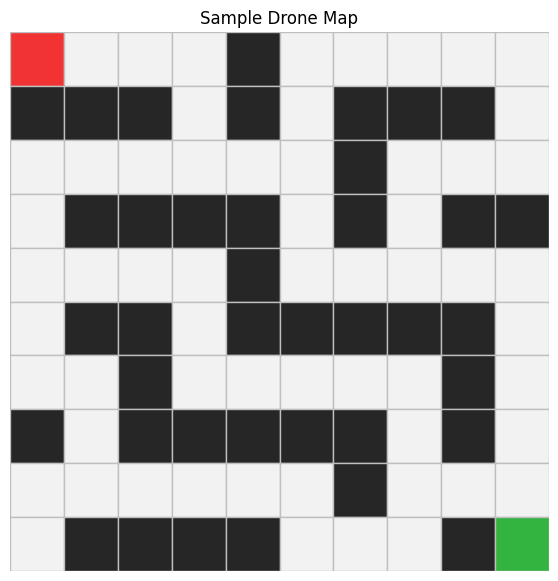

In [10]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [11]:
"""Section 8"""
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        state = node.state
        for action in problem.actions(state):
            next_state = problem.result(state,action)
            cost = node.path_cost + problem.action_cost(state,action, next_state)
            yield Node(state =next_state, parent= node, action =action,path_cost=cost)


    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [12]:
"""Section 9"""
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        node = Node(
            state=problem.initial_state(),
            parent=None,
            action=None,
            path_cost=0
        )

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1
            )
        frontier = deque([node])
        reached={node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem,node):

                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(
                        max_frontier_size,
                        len(frontier)
                    )
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
            )

        raise NotImplementedError("Complete BreadthFirstSearch.search")

In [13]:
"""Section 10"""
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        node=Node(
            state = problem.initial_state(),
            parent=None,
            action=None,
            path_cost=0
        )
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1
            )
        frontier=[node]
        reached={node.state}

        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            children = list(self.expand(problem, node))
            for child in reversed(children):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )


        raise NotImplementedError("Complete DepthFirstSearch.search")

In [14]:
"""Section 11"""
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"
        initial_node = Node(problem.initial_state())
        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
            return node, "success"

        if node.depth >= limit:
            return None, "cutoff"

        metrics["nodes_expanded"] += 1
        cutoff_occurred = False
        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue
            metrics["max_stack_size"] = max(
                metrics["max_stack_size"],
                current_stack_size + 1
            )

            result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=current_stack_size + 1
            )

            if status == "success":
                return result, "success"
            if status == "cutoff":
                cutoff_occurred = True
        if cutoff_occurred:
            return None, "cutoff"

        return None, "failure"

        raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")


In [15]:
"""Section 12"""
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        total_nodes_expanded=0
        max_stack_size=0

        for limit in range(1, max_depth + 1):
            result = dls.search(problem, limit=limit)
            iteration_log.append((limit, result.status))
            total_nodes_expanded += result.nodes_expanded

            max_stack_size = max(
                max_stack_size,
                result.max_frontier_size
            )

            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                )
            if result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,
                    limit=limit
                )
            return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=0,
            limit=max_depth)


        raise NotImplementedError("Complete IterativeDeepeningSearch.search")

In [16]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,cutoff,30.0,NaN,NaN,1,2,0


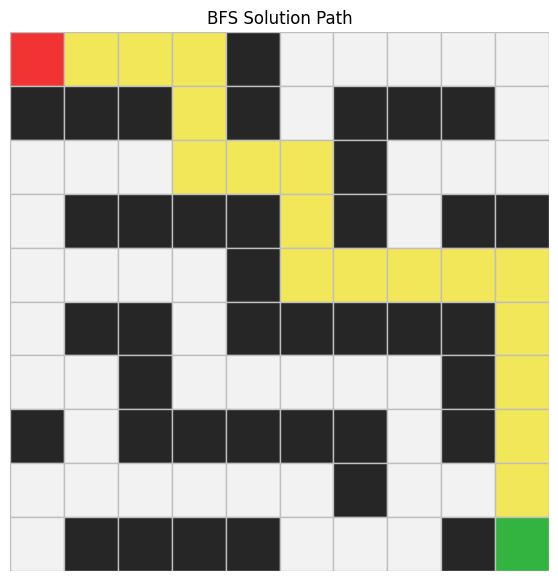

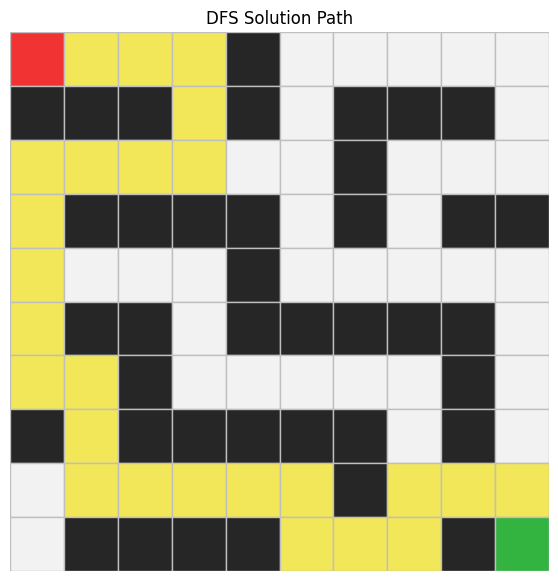

In [17]:
"""Section 13"""
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [18]:
"""Section 14"""
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0,0,0,0,0,0,0,0],
    [1,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,1,0],
    [0,1,1,1,1,0,1,0],
    [0,1,0,0,0,0,1,0],
    [0,1,0,1,1,1,1,0],
    [0,0,0,0,0,0,0,0],
]

custom_start_1 = (0,0)
custom_goal_1 = (6,7)


# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
     bfs.search(custom_problem_1),
     dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
  ids.search(custom_problem_1, max_depth=20),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,13.0,13.0,13,1,13
1,DFS,success,NaN,13.0,13.0,13,1,13
2,DLS,success,20.0,13.0,13.0,13,14,0
3,IDS,cutoff,20.0,NaN,NaN,1,2,0


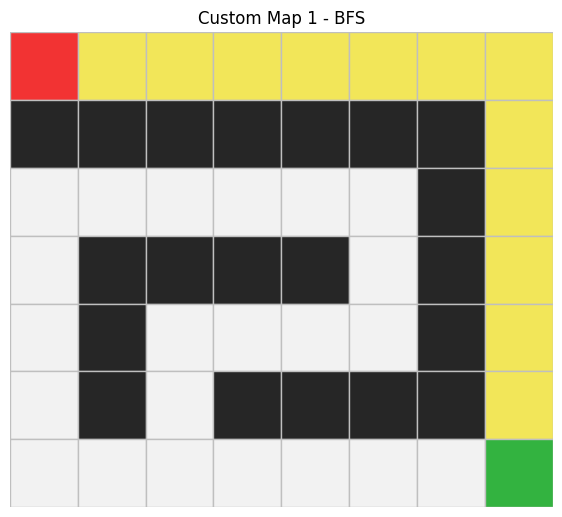

In [19]:
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    title="Custom Map 1 - BFS"
)

In [20]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [

    [0,0,0,0,0,0,0,0],
    [0,1,1,1,1,1,1,0],
    [0,0,0,0,0,0,1,0],
    [1,1,1,1,1,0,1,0],
    [0,0,0,0,1,0,1,0],
    [0,1,1,0,1,0,1,0],
    [0,1,0,0,0,0,1,0],
    [0,1,0,1,1,1,1,0],
    [0,0,0,0,0,0,0,0],
]

custom_start_2 = (0,0)
custom_goal_2 = (8,7)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
   bfs.search(custom_problem_2),
     dfs.search(custom_problem_2),
     dls.search(custom_problem_2, limit=20),
     ids.search(custom_problem_2, max_depth=30),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,15.0,15.0,30,3,32
1,DFS,success,NaN,29.0,29.0,30,4,32
2,DLS,success,20.0,15.0,15.0,43,21,0
3,IDS,cutoff,30.0,NaN,NaN,1,2,0


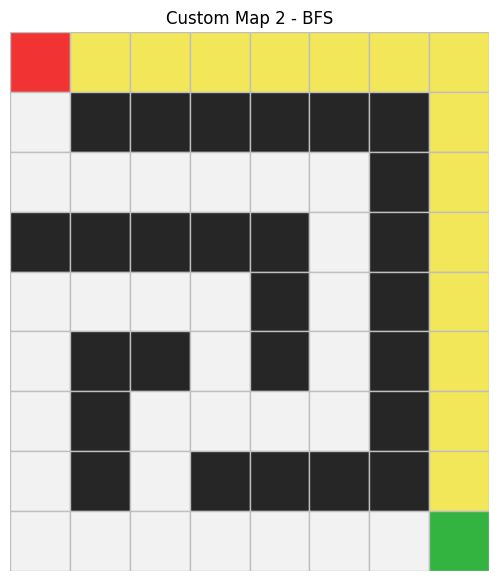

In [21]:
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[0].path,
    title="Custom Map 2 - BFS"
)

 15.1 Problem Formulation

### 1. What is a state in this lab?

A state is the drone's current position on the grid, usually represented by its row and column coordinates.

### 2. What is an action?

An action is a valid movement the drone can make from its current position, such as moving up, down, left, or right.

### 3. What does the result function do?

The result function takes a state and an action and returns the new state reached after performing that action.

### 4. Why is it useful to separate the problem definition from the search algorithm?

Separating them makes the search algorithms reusable. The same BFS, DFS, DLS, or IDS algorithm can solve different problems as long as the problem provides states, actions, and results in the required format.



# 15.2 BFS

### 1. Why does BFS use a FIFO queue?

BFS explores nodes level by level. A FIFO queue ensures that the oldest discovered node is explored first, preserving this level-order exploration.

### 2. Why does BFS find the shortest path in terms of number of steps on the unweighted grid?

BFS explores all nodes at depth 1 before depth 2, all nodes at depth 2 before depth 3, and so on. Therefore, the first time it reaches the goal, it has found the path with the fewest moves.

### 3. What role does the reached set play in BFS?

The reached set keeps track of states that have already been visited. It prevents duplicate exploration, avoids cycles, and reduces unnecessary work.



# 15.3 DFS

### 1. Why does DFS use a stack?

A stack follows Last-In-First-Out (LIFO) order, allowing DFS to continue exploring the most recently discovered path as deeply as possible before backtracking.

### 2. Is DFS guaranteed to find the shortest path? Explain.

No. DFS returns the first solution it finds, which may not be the shortest path. A shorter path may exist elsewhere in the search tree.

### 3. Under what conditions can DFS use less memory than BFS?

DFS only stores the current path and a small number of unexplored branches, while BFS stores an entire frontier. Therefore, DFS uses much less memory in large or deep search spaces.

### 4. Under what conditions can DFS perform badly?

DFS performs poorly when the search space contains very deep branches, cycles, or when the goal is located near the root but DFS explores a deep incorrect path first.


# 15.4 DLS

### 1. What happens when the depth limit is too small?

The search stops before reaching the goal and returns a cutoff result even if a solution exists deeper in the search space.

### 2. What is the meaning of "cutoff"?

A cutoff means the search reached the depth limit before determining whether a solution exists beyond that limit.

### 3. How is DLS different from ordinary DFS?

DLS behaves like DFS but imposes a maximum depth. DFS can continue indefinitely, while DLS stops once the specified depth limit is reached.

### 4. Why do we use path-cycle checking in DLS?

Path-cycle checking prevents the algorithm from repeatedly visiting states already on the current path, avoiding infinite loops and unnecessary exploration.



# 15.5 IDS

### 1. Why does IDS repeat DLS with increasing limits?

The correct depth of the solution is usually unknown. IDS gradually increases the limit until the goal is found.

### 2. Why can IDS be complete even though DLS with a small limit is not?

Although individual DLS runs may fail due to small limits, IDS eventually reaches a depth limit large enough to include the goal, guaranteeing that the solution will be found if one exists.

### 3. Why does IDS use less memory than BFS?

IDS uses the memory requirements of DFS during each iteration, storing only a single path rather than an entire frontier of nodes.

### 4. What is the cost of repeatedly searching from the root?

IDS re-expands upper-level nodes multiple times. This increases computation time compared to BFS, although the memory savings often make the trade-off worthwhile.



# 15.6 Real-World Drone Context

### 1. In a real drone application, what might make one route safer or more practical than another?

Factors such as weather conditions, wind speed, battery consumption, obstacle density, restricted airspace, signal strength, and safety risks may make one route preferable to another.

### 2. Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.

I would choose BFS because it guarantees finding the path with the fewest moves on an unweighted grid.

### 3. Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.

I would choose Depth-Limited Search (DLS) because it explicitly restricts the maximum search depth, preventing the drone from exploring beyond a chosen limit.

### 4. What limitations does this grid model have compared with real drone navigation?

The grid model is highly simplified. Real drones operate in continuous 3D space and must account for changing weather, battery levels, moving obstacles, uncertainty, sensor errors, and dynamic environments that are not represented in a simple grid.